# Project Title:
### Predictive Modeling for Customer Churn Analysis Using Machine Learning


##  Feature Descriptions for Customer Churn Dataset

- **Churn**: Target variable indicating whether the customer has churned (1 = Yes, 0 = No).

### Customer Profile Features:
- **Names**: Full name of the customer (used for identification, not analysis).
- **Age**: Age of the customer in years.
- **Location**: Geographic location or region of the customer.
- **Company**: Name of the company the customer is associated with.

### Service & Usage Features:
- **Total_Purchase**: Total amount spent by the customer over time.
- **Num_Sites**: Number of platforms or websites the customer is using.
- **Years**: Number of years the customer has been with the company.
- **Onboard_date**: Date when the customer was first onboarded.

### Relationship Feature:
- **Account_Manager**: Binary indicator showing if the customer has a dedicated account manager (1 = Yes, 0 = No).


##  Import Libraries

In [5]:
#  Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc, roc_auc_score
import warnings
warnings.filterwarnings("ignore")

# Load the Customer_Churn dataset

In [6]:
# Load the uploaded dataset
df = pd.read_csv("customer_churn.csv")


In [7]:
df.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1


# Information of dataset

In [8]:
df.shape

(900, 10)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Names            900 non-null    object 
 1   Age              900 non-null    float64
 2   Total_Purchase   900 non-null    float64
 3   Account_Manager  900 non-null    int64  
 4   Years            900 non-null    float64
 5   Num_Sites        900 non-null    float64
 6   Onboard_date     900 non-null    object 
 7   Location         900 non-null    object 
 8   Company          900 non-null    object 
 9   Churn            900 non-null    int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 70.4+ KB


# Check The Column Names

In [10]:
df.columns

Index(['Names', 'Age', 'Total_Purchase', 'Account_Manager', 'Years',
       'Num_Sites', 'Onboard_date', 'Location', 'Company', 'Churn'],
      dtype='object')

# Summary Statistics

In [11]:
df.describe()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,41.816667,10062.824033,0.481111,5.273156,8.587778,0.166667
std,6.127560,2408.644532,0.499921,1.274449,1.764836,0.372885
min,22.000000,100.000000,0.000000,1.000000,3.000000,0.000000
25%,38.000000,8497.122500,0.000000,4.450000,7.000000,0.000000
50%,42.000000,10045.870000,0.000000,5.215000,8.000000,0.000000
75%,46.000000,11760.105000,1.000000,6.110000,10.000000,0.000000
max,65.000000,18026.010000,1.000000,9.150000,14.000000,1.000000


# Check The Missing Values

In [12]:
df.isnull().sum()

,0
Names,0
Age,0
Total_Purchase,0
Account_Manager,0
Years,0
Num_Sites,0
Onboard_date,0
Location,0
Company,0
Churn,0


# Check The Unique Values

In [13]:
df.nunique()

,0
Names,899
Age,36
Total_Purchase,900
Account_Manager,2
Years,418
Num_Sites,12
Onboard_date,900
Location,900
Company,873
Churn,2


# Check The Duplicate Values

In [14]:
# check the duplicate values
df.duplicated().sum()


0

# Data Cleaning

In [15]:
# Convert 'Age', 'Years', and 'Num_Sites' columns to integer type
df['Age'] = df['Age'].astype(int)
df['Years'] = df['Years'].astype(int)
df['Num_Sites'] = df['Num_Sites'].astype(int)



In [16]:

# Drop high-cardinality or irrelevant columns
df_cleaned = df.drop(columns=["Names", "Onboard_date", "Location", "Company"])
df_cleaned

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn
0,42,11066.80,0,7,8,1
1,41,11916.22,0,6,11,1
2,38,12884.75,0,6,12,1
3,42,8010.76,0,6,10,1
4,37,9191.58,0,5,9,1
...,...,...,...,...,...,...
895,42,12800.82,1,3,8,0
896,52,9893.92,0,6,7,0
897,45,12056.18,0,5,4,0
898,51,6517.93,1,5,10,0


# Top 5 Rows

In [17]:
df_cleaned.head()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn
0,42,11066.80,0,7,8,1
1,41,11916.22,0,6,11,1
2,38,12884.75,0,6,12,1
3,42,8010.76,0,6,10,1
4,37,9191.58,0,5,9,1


## Correlation Matrix

In [18]:
corr_matrix=df.corr(numeric_only=True)
corr_matrix

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn
Age,1.000000,-0.037208,-0.014749,0.018848,-0.006070,0.085926
Total_Purchase,-0.037208,1.000000,0.015856,-0.011832,-0.003390,0.024031
Account_Manager,-0.014749,0.015856,1.000000,0.034856,0.033401,0.070611
Years,0.018848,-0.011832,0.034856,1.000000,0.037048,0.199667
Num_Sites,-0.006070,-0.003390,0.033401,0.037048,1.000000,0.525398
Churn,0.085926,0.024031,0.070611,0.199667,0.525398,1.000000


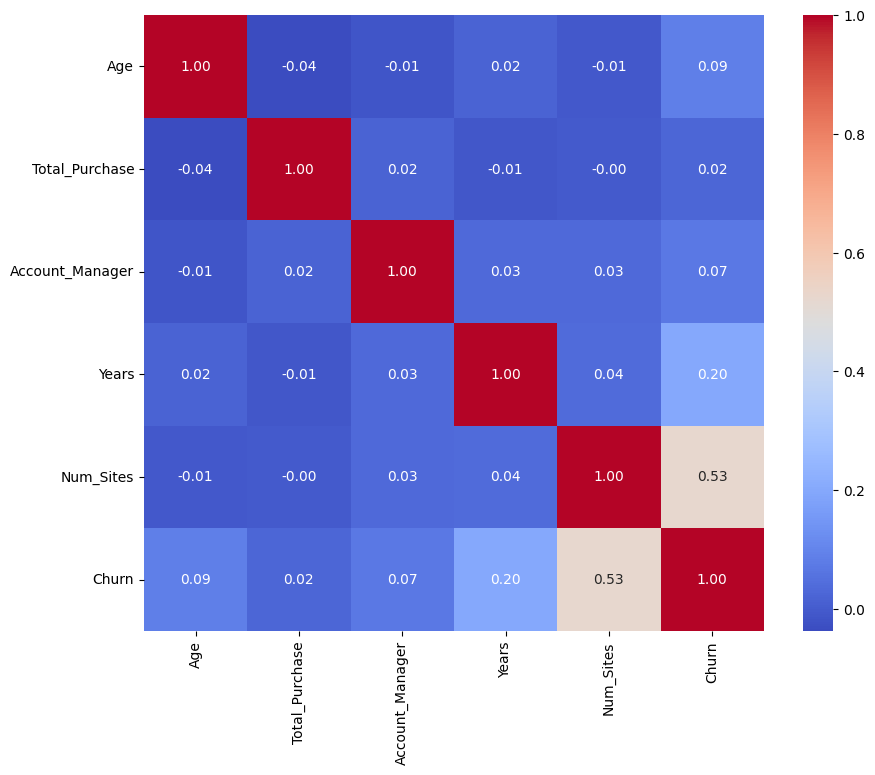

In [19]:

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm",fmt=".2f")
plt.show()

# Define independent variables (X) and dependent variable (Y)

In [20]:
import numpy as np
np.random.seed(5)

In [21]:
x=df_cleaned.drop("Churn",axis=1)
y=df_cleaned["Churn"]


# Split Data into Training & Testing Sets

In [22]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)

# Defining & Training  All The Model For Choosing the Best Model

---



In [23]:
# Test Of Multiple Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB()
}



results = []
for name, model in models.items():
    # Model Training
    model.fit(x_train, y_train)

    # For Predictions
    y_pred = model.predict(x_test)

    # Check Performance
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print("="*60)
    results.append([name, acc, f1])

    # Classification Report
    print(f"\nModel: {name} \n")
    print("Accuracy:", round(acc, 4))
    print("F1 Score:", round(f1, 4))
    print("="*60)
    print("Classification Report:\n", classification_report(y_test, y_pred))


Model: Logistic Regression 

Accuracy: 0.9333
F1 Score: 0.7273
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.99      0.96       231
           1       0.89      0.62      0.73        39

    accuracy                           0.93       270
   macro avg       0.91      0.80      0.84       270
weighted avg       0.93      0.93      0.93       270


Model: Decision Tree 

Accuracy: 0.863
F1 Score: 0.5067
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.93      0.92       231
           1       0.53      0.49      0.51        39

    accuracy                           0.86       270
   macro avg       0.72      0.71      0.71       270
weighted avg       0.86      0.86      0.86       270


Model: Random Forest 

Accuracy: 0.9074
F1 Score: 0.6032
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.98      0

# Results Comparison

In [24]:
# Summary table
# Results Comparison
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'F1 Score'])
print("\nModels Comparison:")
results_df.sort_values('F1 Score', ascending=False)


Models Comparison:


,Model,Accuracy,F1 Score
0,Logistic Regression,0.933333,0.727273
3,Naive Bayes,0.914815,0.634921
2,Random Forest,0.907407,0.603175
1,Decision Tree,0.862963,0.506667


# Model Performance

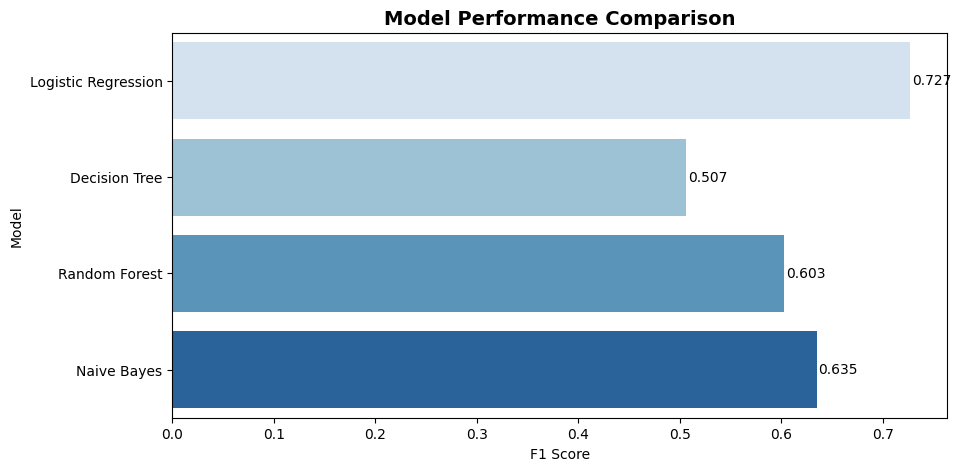

In [25]:

# Plot Model Performance
plt.figure(figsize=(10, 5))
ax = sns.barplot(x="F1 Score", y="Model", data=results_df, palette="Blues")

# Add annotations (F1 Score on bars)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=10, color="black", padding=1)

# Set title and limits
plt.title("Model Performance Comparison", fontsize=14, fontweight="bold")
#plt.xlim(0, 1)  #F1 Score range

# Show plot
plt.show()

# Check The Class is Balance or imbalance

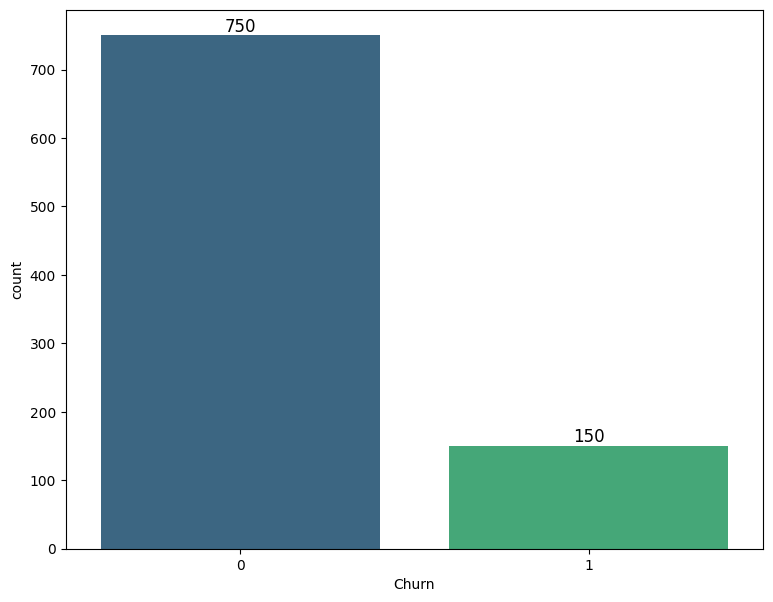

In [26]:
plt.figure(figsize=(9,7))
m=sns.countplot(data=df_cleaned,x="Churn",palette='viridis')

for container in m.containers:
    m.bar_label(container,  fontsize=12)


plt.show()


* Class imbalance in the dataset leads to biased models favoring the majority class

# Threshold Tuning for Class Imbalance

In [71]:
import numpy as np
np.random.seed(5)

In [72]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)

# Use GaussianNB Model For Threshold Tuning

In [70]:
# Use GaussianNB model
GNB = GaussianNB()

# Model Training
GNB.fit(x_train, y_train)

# For Predicting Probabilities
probs = GNB.predict_proba(x_test)[:, 1]  # Probabilities for class 1

# Apply Threshold for Prediction
threshold = 0.3
y_pred = (probs >= threshold).astype(int)

# Check Performance
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print Results for Logistic Regression Model
print("_" * 60)
print(f"\nModel: GaussianNB\n")
print("Threshold Used:", threshold)
print("Accuracy:", round(acc, 4))
print("F1 Score:", round(f1, 4))
print("-" * 60)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("-" * 60)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("-" * 60)
roc_score = roc_auc_score(y_test, probs)
print("\nROC AUC Score:", roc_score)
print("_" * 60)

____________________________________________________________

Model: GaussianNB

Threshold Used: 0.3
Accuracy: 0.9296
F1 Score: 0.7711
------------------------------------------------------------
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.95      0.96       231
           1       0.73      0.82      0.77        39

    accuracy                           0.93       270
   macro avg       0.85      0.88      0.86       270
weighted avg       0.93      0.93      0.93       270

------------------------------------------------------------
Confusion Matrix:
[[219  12]
 [  7  32]]
------------------------------------------------------------

ROC AUC Score: 0.959151959151959
____________________________________________________________



# Use Logistic Regression Model For Threshold Tuning

In [94]:
# Use Logistic Regression model
Lr = LogisticRegression(max_iter=1000)

# Model Training
Lr.fit(x_train, y_train)

# For Predicting Probabilities
probs = Lr.predict_proba(x_test)[:, 1]  # Probabilities for class 1

# Apply Threshold for Prediction
threshold = 0.3
y_pred = (probs >= threshold).astype(int)

# Check Performance
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print Results for Logistic Regression Model
print("_" * 60)
print(f"\nModel: Logistic Regression\n")
print("Threshold Used:", threshold)
print("Accuracy:", round(acc, 4))
print("F1 Score:", round(f1, 4))
print("-" * 60)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("-" * 60)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("-" * 60)
roc_score = roc_auc_score(y_test, probs)
print("\nROC AUC Score:", roc_score)
print("_" * 60)


____________________________________________________________

Model: Logistic Regression

Threshold Used: 0.3
Accuracy: 0.9259
F1 Score: 0.7561
------------------------------------------------------------
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.95      0.96       231
           1       0.72      0.79      0.76        39

    accuracy                           0.93       270
   macro avg       0.84      0.87      0.86       270
weighted avg       0.93      0.93      0.93       270

------------------------------------------------------------
Confusion Matrix:
[[219  12]
 [  8  31]]
------------------------------------------------------------

ROC AUC Score: 0.9592629592629592
____________________________________________________________



# Use Random Forest Classifier Model With SMOTE

In [96]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Apply SMOTE on the training data
smote = SMOTE(random_state=42)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

# Train the model
Rfc = RandomForestClassifier(random_state=42)
Rfc.fit(x_train_resampled, y_train_resampled)

# Predict on test data
y_pred = Rfc.predict(x_test)

# For Predicting Probabilities
probs = Rfc.predict_proba(x_test)[:, 1]  # Probabilities for class 1


# Check Performance
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("_" * 60)
print(f"\nModel: RandomForestClassifier with SMOTE\n")
print("Accuracy:", round(acc, 5))
print("F1 Score:", round(f1, 5))
print("-" * 60)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("-" * 60)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("-" * 60)
roc_score = roc_auc_score(y_test, probs)
print("\nROC AUC Score:", roc_score)
print("_" * 60)


____________________________________________________________

Model: RandomForestClassifier with SMOTE

Accuracy: 0.87037
F1 Score: 0.60674
------------------------------------------------------------
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.90      0.92       231
           1       0.54      0.69      0.61        39

    accuracy                           0.87       270
   macro avg       0.74      0.80      0.76       270
weighted avg       0.89      0.87      0.88       270

------------------------------------------------------------
Confusion Matrix:
[[208  23]
 [ 12  27]]
------------------------------------------------------------

ROC AUC Score: 0.9159174159174159
____________________________________________________________



# Use Balanced Random Forest Classifier Model

In [98]:
from imblearn.ensemble import BalancedRandomForestClassifier

# Create and train BalancedRandomForest model
Brf = BalancedRandomForestClassifier(random_state=42, n_estimators=100)
Brf.fit(x_train, y_train)

# Predictions
y_pred_brf = Brf.predict(x_test)
y_proba_brf = Brf.predict_proba(x_test)[:, 1]

# Evaluation
print("_" * 60)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_brf))
print("-" * 60)
print("Classification Report:\n", classification_report(y_test, y_pred_brf))
print("-" * 60)
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_brf))
print("_" * 60)


____________________________________________________________
Confusion Matrix:
 [[206  25]
 [  6  33]]
------------------------------------------------------------
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.89      0.93       231
           1       0.57      0.85      0.68        39

    accuracy                           0.89       270
   macro avg       0.77      0.87      0.81       270
weighted avg       0.91      0.89      0.89       270

------------------------------------------------------------
ROC AUC Score: 0.9413919413919414
____________________________________________________________


## Interpretation:
To manage class imbalance, we have applied threshold tuning, where the model's probability threshold is adjusted to improve predictions for the minority class. This approach prevents the model from focusing too much on the majority class predictions and allows it to more accurately predict the minority class.

I applied various machine learning models to my imbalanced dataset, including **GaussianNB**, **Logistic Regression**, **RandomForestClassifier with SMOTE**, and **BalancedRandomForestClassifier**. GaussianNB showed a balanced performance with a good F1-score and ROC AUC score, while Logistic Regression also provided similar results with decent precision and recall. The RandomForest model with SMOTE performed slightly worse, especially for the minority class (class 1), as its F1-score and recall were comparatively lower. Among all, the **BalancedRandomForestClassifier** gave the best **recall** for class 1, which means it was the most effective in identifying the minority class correctly. Since my main objective is to **give more importance to class 1 and reduce false negatives**, I chose **BalancedRandomForestClassifier**. This model is ideal in scenarios where positive cases are fewer but critical to detect — such as in disease, fraud detection or churn prediction. Therefore, I selected this model for my final decision.


# Choose The Best Model For Imbalnced Class
* Balanced Random Forest Classifier is the best model for minority class

In [105]:
# Create and train BalancedRandomForest model
Best_model = BalancedRandomForestClassifier(random_state=42, n_estimators=100)
Best_model.fit(x_train, y_train)

# Predictions
y_pred_brf = Best_model.predict(x_test)
y_proba_brf = Best_model.predict_proba(x_test)[:, 1]

# Confusion Matrix

In [106]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_brf))

Confusion Matrix:
[[206  25]
 [  6  33]]


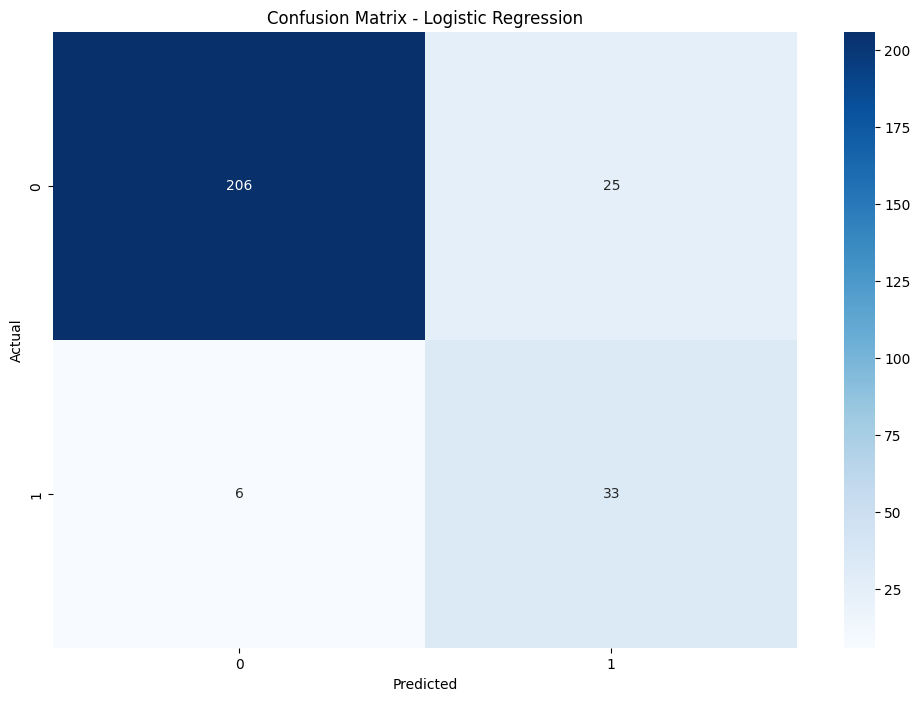

In [107]:
plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_test, y_pred_brf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# ROC AUC Score

In [108]:

roc_score = roc_auc_score(y_test, y_proba_brf)
print("\nROC AUC Score:", roc_score)



ROC AUC Score: 0.9413919413919414


# Plotting the ROC Curve

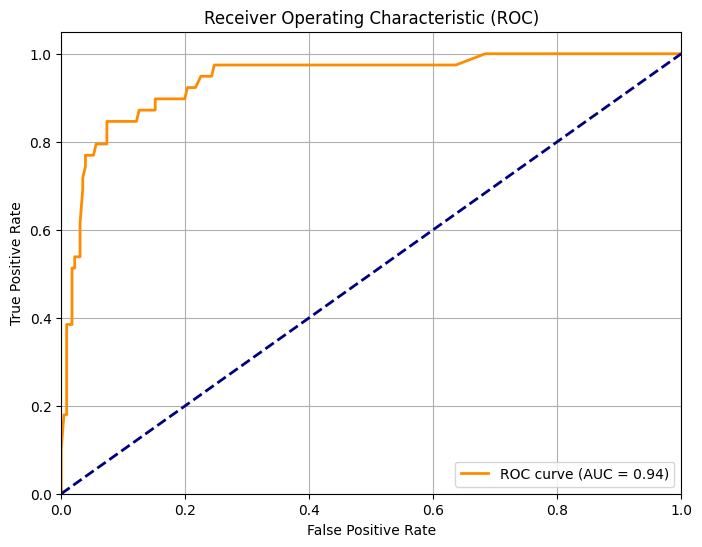

In [109]:

# Calculate FPR, TPR, and Thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_proba_brf)

# Calculate AUC
roc_auc = auc(fpr, tpr)

# Plotting the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Random chance line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# Prediction

### Actual Data

In [ ]:
df_cleaned[[
    'Age',
    'Total_Purchase',
    'Account_Manager',
    'Years',
    'Num_Sites',
    'Churn'
]].head(5)


,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn
0,42,11066.80,0,7,8,1
1,41,11916.22,0,6,11,1
2,38,12884.75,0,6,12,1
3,42,8010.76,0,6,10,1
4,37,9191.58,0,5,9,1


#### Customer Charn data

In [121]:
new_customer_churn = pd.DataFrame([{'Age': 37,'Total_Purchase': 9191.58	,'Account_Manager': 0,'Years': 5,'Num_Sites': 9}])

In [122]:
new_customer_churn

,Age,Total_Purchase,Account_Manager,Years,Num_Sites
0,37,9191.58,0,5,9


In [123]:
# Prediction
prediction = Best_model.predict(new_customer_churn)
prediction_proba = Best_model.predict_proba(new_customer_churn)

# Result Display
print("\nNew Customer Prediction:")
print("Predicted Class:", "Churn" if prediction[0] == 1 else "No Churn")
print("Probability [Churn, No Churn]:", prediction_proba[0])



New Customer Prediction:
Predicted Class: Churn
Probability [Churn, No Churn]: [0.27 0.73]


### Actual Data

In [ ]:
df_cleaned[['Age','Total_Purchase','Account_Manager','Years','Num_Sites','Churn']].tail(5)


,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn
895,42,12800.82,1,3,8,0
896,52,9893.92,0,6,7,0
897,45,12056.18,0,5,4,0
898,51,6517.93,1,5,10,0
899,39,9315.60,1,5,10,0


#### Customer No Churn data

In [ ]:
new_customer_no_churn = pd.DataFrame([{'Age': 39, 'Total_Purchase': 9315.60, 'Account_Manager': 1, 'Years': 5, 'Num_Sites': 10}])

In [ ]:
new_customer_no_churn

,Age,Total_Purchase,Account_Manager,Years,Num_Sites
0,39,9315.6,1,5,10


In [ ]:
# Prediction
prediction = Best_model.predict(new_customer_no_churn)
prediction_proba = Best_model.predict_proba(new_customer_no_churn)

# Result Display
print("\nNew Customer Prediction:")
print("Predicted Class:", "Churn (Customer will leave)" if prediction[0] == 1 else "No Churn (Customer will stay)")
print("Probability [No Churn, Churn]:", prediction_proba[0])



New Customer Prediction:
Predicted Class: No Churn (Customer will stay)
Probability [No Churn, Churn]: [0.56 0.44]
